In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np # this is the only math-ish library, you are allowed to import!! Do not import OpenCV!
%matplotlib inline

## PART 1.1 Implement CornerDetect

In [8]:
def conv_2d(img, kernel, use_vectorized=True):

    k_height, k_width = kernel.shape
    pad_h = k_height // 2
    pad_w = k_width // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    if use_vectorized:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(padded, (k_height, k_width))
        output = np.einsum('ijkl,kl->ij', windows, kernel)
    else:
        output = np.zeros_like(img, dtype=np.float64)
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                output[i, j] = np.sum(padded[i:i+k_height, j:j+k_width] * kernel)
                
    return output


def cornerDetect(img, winSize=7, type=0) -> np.array:
    '''
    Parameters:
        img: we are only doing grayscale images
        winSize: height/width of window for summation in pixels[square window, so one number is enough]
        type: { 0: Eigenvalue, 1: Harris }

    Returns:
        np.array: The corner strength as a numpy array that has the same size as your input image
    '''

    '''
    The steps the function has to do are:
    1) Filter img with Sobel kernel to obtain derivatives Ix, Iy
    2) For each pixel in img, determine second moment matrix H summed up over the square window [see lecture slides]
    3) Depending on type, either determine the minimum eigenvalue [using numpy functionality] OR the Harris corner measure and store in return array
    '''

    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    Ix = conv_2d(img, sobel_x)
    Iy = conv_2d(img, sobel_y)

    Ix2 = Ix ** 2
    Iy2 = Iy ** 2
    Ixy = Ix * Iy

    # window = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
    window = np.ones((winSize, winSize))
    Sx2 = conv_2d(Ix2, window)
    Sy2 = conv_2d(Iy2, window)
    Sxy = conv_2d(Ixy, window)

    # trace(M) = λ1+λ2 = a+d
    # det(M) = λ1*λ2 = ad-bc = Sx2*Sy2-Sxy^2
    traceM = Sx2 + Sy2
    detM = Sx2 * Sy2 - Sxy ** 2 

    if type == 0: # eigenvalue
        corner_strength = np.zeros_like(detM)
        h, w = img.shape
        for i in range(h):
            for j in range(w):
                H = np.array([
                    [Sx2[i,j], Sxy[i,j]],
                    [Sxy[i,j], Sy2[i,j]]
                ])
                eigen_values = np.linalg.eigvals(H)
                corner_strength[i, j] = np.min(eigen_values)
    else: # Harris
        k = 0.04
        corner_strength = detM - k * (traceM ** 2)
        
    return corner_strength

## PART 1.2. Evaluate Corner Detection

In [3]:
%pip install wget
import wget
import os
from PIL import Image

url = 'https://img.freepik.com/free-vector/abstract-distorted-checkered-background_23-2148965764.jpg' \
'?t=st=1650245746~exp=1650246346~hmac=29a27d58604684adf6c7a8140834106058f08462598935fa2273b65e54f72461&w=1800'

filename = 'distorted-checkered-background'
jpg = f'{filename}.jpg'
png = f'{filename}.png'
if not os.path.exists(jpg):
    wget.download(url, jpg)

# Convert JPG to PNG
Image.open(jpg).save(png, format='png')

Note: you may need to restart the kernel to use updated packages.


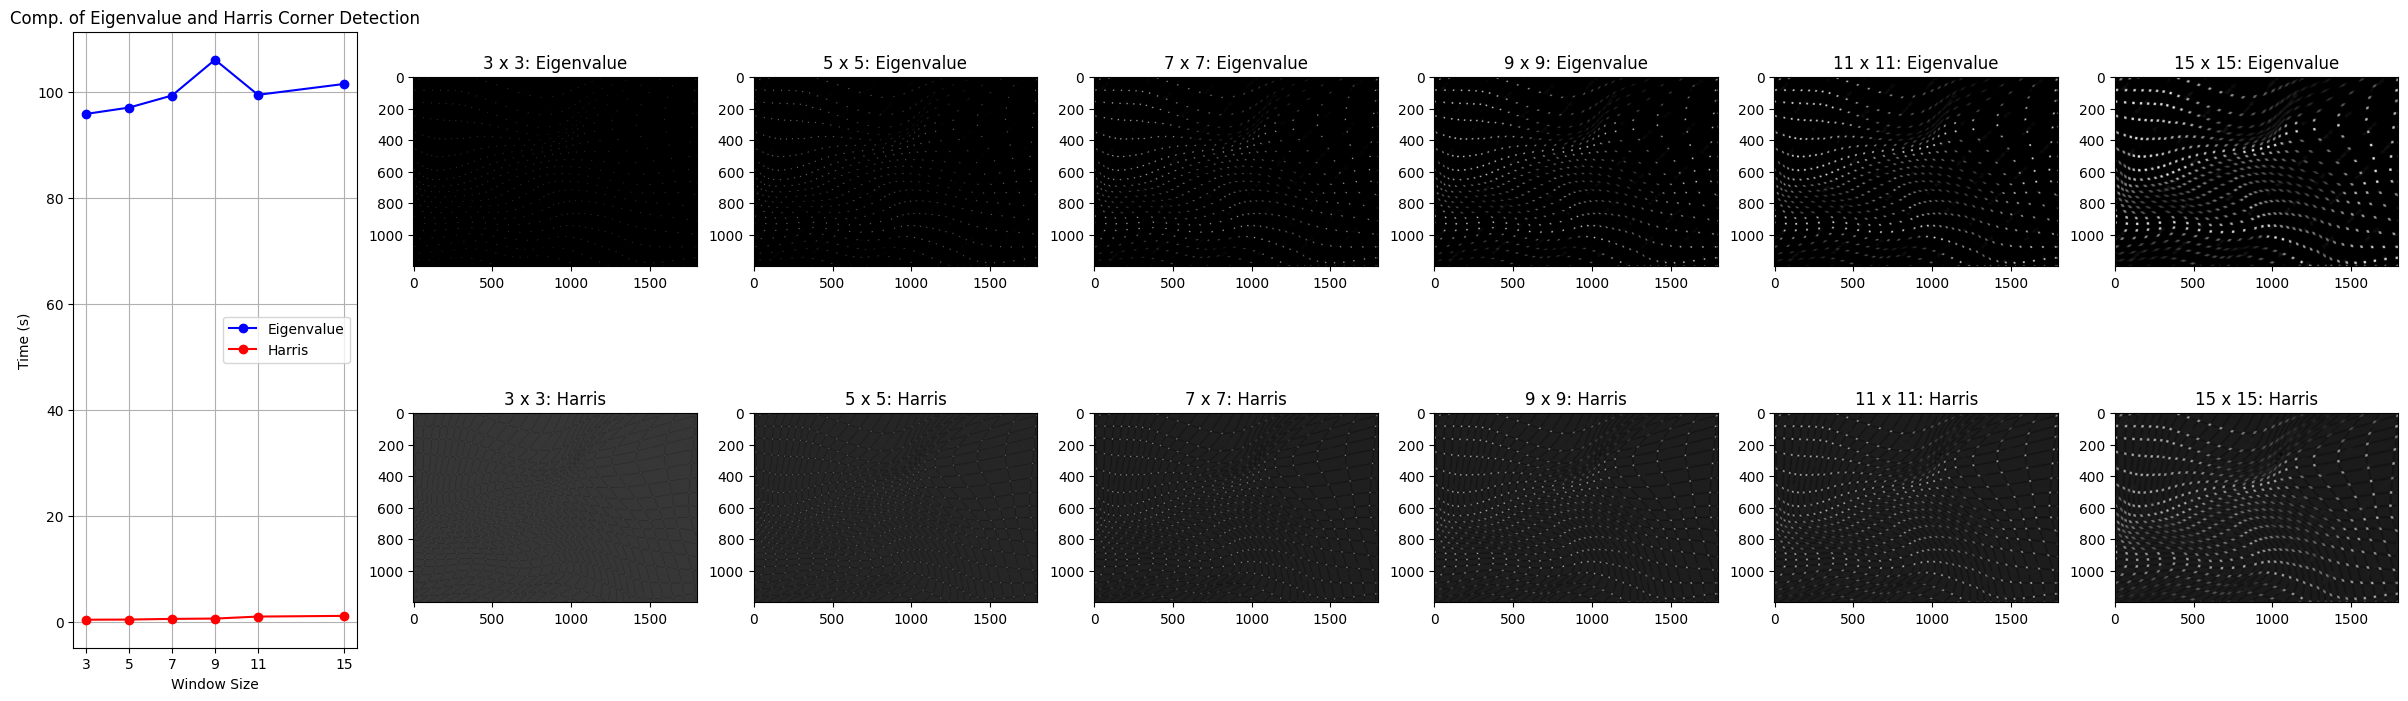

In [9]:
import time
import matplotlib.gridspec as gridspec


def record(func):
    start = time.time()
    result = func()
    end = time.time()
    elapsed = (end - start)
    return (result, elapsed)
    

def plot_results(title, results, indices):
    num = len(results)

    figure = plt.figure(figsize=(5*num, 8))
    gs = gridspec.GridSpec(2, num+1, figure=figure)

    ax_time = figure.add_subplot(gs[0:2, 0])
    ax_time.set_title(title)
    ax_time.grid(True)
    ax_time.set_xlabel('Window Size')
    ax_time.set_ylabel('Time (s)')
    ax_time.set_xticks(ticks=indices)
    ax_time.plot(indices, [result[0][1] for result in results], label='Eigenvalue', color='blue', marker='o')
    ax_time.plot(indices, [result[1][1] for result in results], label='Harris', color='red', marker='o')
    ax_time.legend(['Eigenvalue', 'Harris'])

    for (i, result) in enumerate(results):
        eigen, harris = result
        eigen_img, _ = eigen
        harris_img, _ = harris
        
        ax = figure.add_subplot(gs[0, 1+i])
        ax.set_title(f'{indices[i]} x {indices[i]}: Eigenvalue')
        ax.imshow(eigen_img, cmap='gray')

        ax = figure.add_subplot(gs[1, i+1])
        ax.set_title(f'{indices[i]} x {indices[i]}: Harris')
        ax.imshow(harris_img, cmap='gray')
    
    plt.show()


def evaluate_corner_detection():
    img = plt.imread(png)
    # Grayscale (ITU-R BT.601)
    img = img @ [0.2989, 0.5870, 0.1140]

    results = []
    window_sizes = [3, 5, 7, 9, 11, 15]
    for size in window_sizes:
        eigen = record(lambda: cornerDetect(img, winSize=size, type=0))
        harris = record(lambda: cornerDetect(img, winSize=size, type=1))
        results.append((eigen, harris))

    plot_results('Comp. of Eigenvalue and Harris Corner Detection', results, window_sizes)

evaluate_corner_detection()

# PART 1.3. Anser the following questions

### 1.3.1. At which window sizes can you detect all “meaningful” corners?


### 1.3.2. Which method is faster – Eigenvalue or Harris? By how much? 